In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [5]:
df.shape

(4685611, 90)

In [6]:
df["label"].value_counts()

label
TFTP             950295
DrDoS_NTP        917607
DrDoS_DNS        893762
DrDoS_SNMP       415000
DrDoS_LDAP       290000
LDAP             290000
MSSQL            190000
UDP              150000
DrDoS_MSSQL      150000
DrDoS_SSDP       106650
DrDoS_UDP        105000
DrDoS_NetBIOS     65000
NetBIOS           55057
BENIGN            53277
Syn               42004
Portmap            5608
UDP-lag            5000
UDPLag             1203
WebDDoS             148
Name: count, dtype: int64

In [7]:
dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
dos_sample = (dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
dos_sample["label"] = "DoS_ATTACK"
dos_sample["label"].value_counts()

label
DoS_ATTACK    50000
Name: count, dtype: int64

In [8]:
non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
non_dos_sample = (non_dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
non_dos_sample["label"] = "NON_DoS_ATTACK"
non_dos_sample["label"].value_counts()

label
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [9]:
attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
attack_sample["label"].value_counts()

label
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [10]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=non_dos_sample.shape[0], replace=False, random_state=42)

In [11]:
benign_sample.shape

(50000, 90)

In [12]:
print(benign_sample["label"].value_counts())

label
BENIGN    50000
Name: count, dtype: int64


In [13]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [14]:
df_sample.shape

(150000, 90)

In [15]:
df_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [16]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


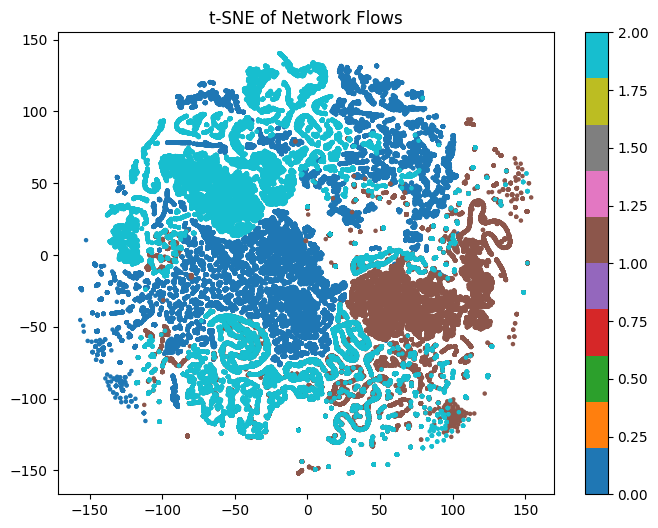

In [17]:
tsne = TSNE(n_components=2)

X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='tab10', s=5)

plt.title("t-SNE of Network Flows")
plt.colorbar(scatter)
plt.show()

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [20]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)

In [21]:
input_size = 88
hidden_size = 128
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
#            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [22]:
model = MultiClassDNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [23]:
num_epochs = 100
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.5968, Val Loss: 0.3906
Epoch 2, Train Loss: 0.3784, Val Loss: 0.3701
Epoch 3, Train Loss: 0.3703, Val Loss: 0.3663
Epoch 4, Train Loss: 0.3678, Val Loss: 0.3659
Epoch 5, Train Loss: 0.3662, Val Loss: 0.3630
Epoch 6, Train Loss: 0.3643, Val Loss: 0.3627
Epoch 7, Train Loss: 0.3638, Val Loss: 0.3619
Epoch 8, Train Loss: 0.3629, Val Loss: 0.3602
Epoch 9, Train Loss: 0.3614, Val Loss: 0.3595
Epoch 10, Train Loss: 0.3605, Val Loss: 0.3589
Epoch 11, Train Loss: 0.3600, Val Loss: 0.3585
Epoch 12, Train Loss: 0.3589, Val Loss: 0.3583
Epoch 13, Train Loss: 0.3592, Val Loss: 0.3578
Epoch 14, Train Loss: 0.3589, Val Loss: 0.3583
Epoch 15, Train Loss: 0.3581, Val Loss: 0.3573
Epoch 16, Train Loss: 0.3579, Val Loss: 0.3570
Epoch 17, Train Loss: 0.3582, Val Loss: 0.3574
Epoch 18, Train Loss: 0.3575, Val Loss: 0.3572
Epoch 19, Train Loss: 0.3572, Val Loss: 0.3568
Epoch 20, Train Loss: 0.3575, Val Loss: 0.3568
Epoch 21, Train Loss: 0.3571, Val Loss: 0.3571
Epoch 22, Train Loss: 

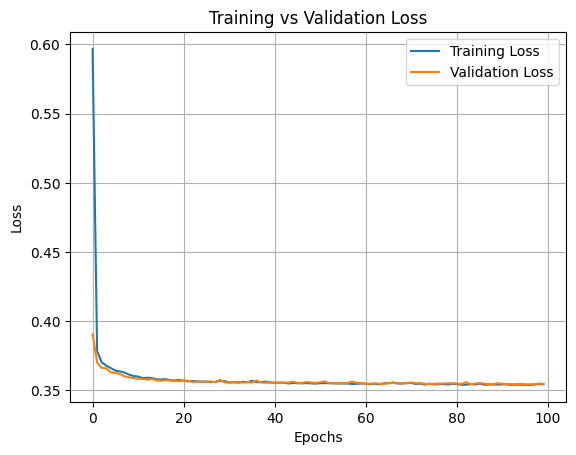

In [24]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [25]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

PermutationExplainer explainer: 1001it [00:43, 22.01it/s]                                                                                                                                                       


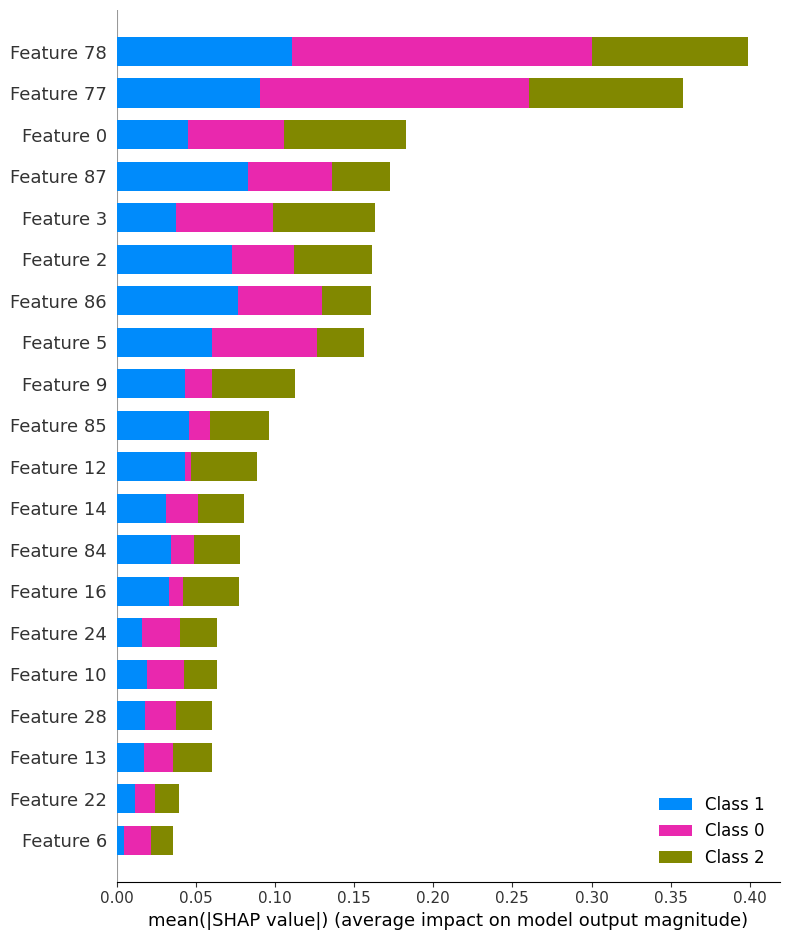

In [26]:
def predict_fn(X):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(X, np.ndarray):
        X = X.values
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = torch.softmax(model(X_tensor), dim=1)
    return outputs.cpu().numpy()
    
rng = np.random.default_rng(42)
X_sample = X.sample(1000, random_state=42).values
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=rng)

In [27]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8906444444444445
Weighted F1: 0.8905941062262388
Macro F1: 0.8905941062262389
ROC-AUC: 0.9726062822222223


In [28]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     15000
    DoS_ATTACK       0.83      0.85      0.84     15000
NON_DoS_ATTACK       0.85      0.82      0.83     15000

      accuracy                           0.89     45000
     macro avg       0.89      0.89      0.89     45000
  weighted avg       0.89      0.89      0.89     45000

